In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import to_rgb
from matplotlib.ticker import MultipleLocator
from adjustText import adjust_text

from scipy.stats import entropy, mannwhitneyu

In [2]:
sample_table = pd.read_csv("../data_processed/sample_table.csv", index_col=0)
otu_rpo = pd.read_csv("../data_processed/otu_rpo.csv", index_col=0)
tax = pd.read_csv("../data_processed/tax.csv", index_col=0)

color_sample_group = {
    'subsurface_sample': "#ad8b56ff",
    'soil': "#85ba89ff",
    'marine_water': "#57a8d1ff",
    'freshwater': "#c2e8e5ff"
}

color_surface_subsurface = {'subsurface': "#ad8b56ff", 'surface': "#c2e8e5ff"}

color_pathway = {
    "cbb_1": "#91cf60",
    "hp_1": "#91bfdb",
    "hphb_1": "#4575b4",
    "dchb_1": "#e0f3f8",
    "wl_1": "#d73027",
    "rtca_1": "#fc8d59"
}

cfp_cols = ["mean_cbb_1", "mean_hp_1", "mean_hphb_1", "mean_dchb_1", "mean_wl_1", "mean_rtca_1"]

ordered_groups = ["surface", "subsurface"]

shared_kos = list(
    set(otu_rpo.index[(otu_rpo[sample_table.index[sample_table["surface_subsurface"] == "surface"]] > 0).any(axis=1)])
    & set(otu_rpo.index[(otu_rpo[sample_table.index[sample_table["surface_subsurface"] == "subsurface"]] > 0).any(axis=1)])
)
shared_otu = otu_rpo.loc[shared_kos]

surface_samples = sample_table.index[sample_table["surface_subsurface"] == "surface"]
subsurface_samples = sample_table.index[sample_table["surface_subsurface"] == "subsurface"]

In [3]:
def star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# CFP Shannon diversity and average abudance 

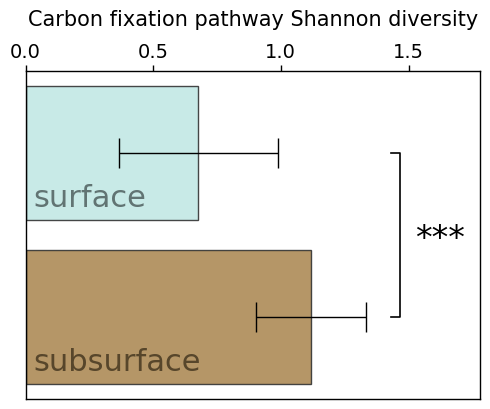

In [4]:
shannon = {}
for g in ordered_groups:
    subset = sample_table.loc[sample_table["surface_subsurface"] == g, cfp_cols]
    vals = subset.div(subset.sum(axis=1), axis=0).apply(entropy, axis=1).values
    shannon[g] = vals[~np.isnan(vals)]

means = [np.mean(shannon[g]) for g in ordered_groups]
stds  = [np.std(shannon[g])  for g in ordered_groups]

_, pval = mannwhitneyu(shannon["surface"], shannon["subsurface"], alternative="two-sided")
s = star(pval)

fig, ax = plt.subplots(figsize=(5, 4.2))
ypos = np.array([1, 0])

ax.barh(
    ypos, means, xerr=stds, capsize=11,
    color=[color_surface_subsurface[g] for g in ordered_groups],
    edgecolor="#333333", linewidth=1, alpha=0.9, height=0.82,
    error_kw={"elinewidth": 1, "capthick": 1}
)

for y, g in zip(ypos, ordered_groups):
    r, gc, b = to_rgb(color_surface_subsurface[g])
    ax.text(0.03, y - 0.27, g, va="center", ha="left", fontsize=22,
            color=(r * 0.5, gc * 0.5, b * 0.5))

ax.set_xlim(0, 1.78)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=14, width=1, length=4, top=True, bottom=False)
ax.set_xlabel("Carbon fixation pathway Shannon diversity", fontsize=15, labelpad=12)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_linewidth(1)

if s:
    x_bracket, arm = 1.43, 0.035
    ax.plot(
        [x_bracket, x_bracket + arm, x_bracket + arm, x_bracket],
        [ypos[1], ypos[1], ypos[0], ypos[0]],
        color="black", linewidth=1.2
    )
    ax.text(x_bracket + arm + 0.06, 0.48, s, va="center", ha="left", fontsize=24)

plt.tight_layout()
plt.savefig("../outputs/CFP_shannon_diversity.svg", transparent=True)
plt.show()

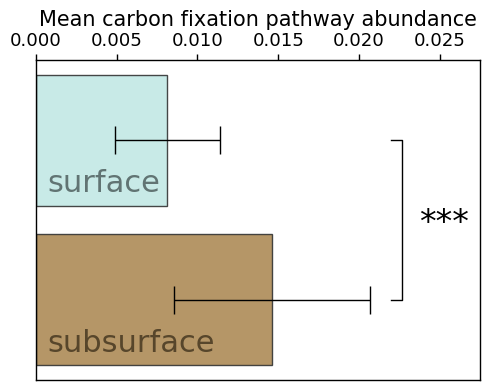

In [5]:
abundance = {}
for g in ordered_groups:
    vals = sample_table.loc[sample_table["surface_subsurface"] == g, "mean_CFP_key_1"].values
    abundance[g] = vals[~np.isnan(vals)]

means = [np.mean(abundance[g]) for g in ordered_groups]
stds  = [np.std(abundance[g]) for g in ordered_groups]

_, pval = mannwhitneyu(abundance["surface"], abundance["subsurface"], alternative="two-sided")
s = star(pval)

fig, ax = plt.subplots(figsize=(5, 4))
ypos = np.array([1, 0])

ax.barh(
    ypos, means, xerr=stds, capsize=10,
    color=[color_surface_subsurface[g] for g in ordered_groups],
    edgecolor="#333333", linewidth=1, alpha=0.9, height=0.82,
    error_kw={"elinewidth": 1, "capthick": 1}
)

for y, g in zip(ypos, ordered_groups):
    r, gc, b = to_rgb(color_surface_subsurface[g])
    ax.text(0.0007, y - 0.27, g, va="center", ha="left", fontsize=22,
            color=(r * 0.5, gc * 0.5, b * 0.5))

ax.set_xlim(0, 0.0275)
ax.xaxis.set_major_locator(MultipleLocator(0.005))
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=13, width=1, length=4, top=True, bottom=False)
ax.set_xlabel("Mean carbon fixation pathway abundance", fontsize=15)
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_linewidth(1)

if s:
    x_bracket, arm = 0.022, 0.0007
    ax.plot(
        [x_bracket, x_bracket + arm, x_bracket + arm, x_bracket],
        [ypos[1], ypos[1], ypos[0], ypos[0]],
        color="black", linewidth=1
    )
    ax.text(x_bracket + arm + 0.001, 0.48, s, va="center", ha="left", fontsize=24)

plt.tight_layout()
plt.savefig("../outputs/CFP_abundance_all_grouped.svg", transparent=True)
plt.show()

# Detail of each CFP

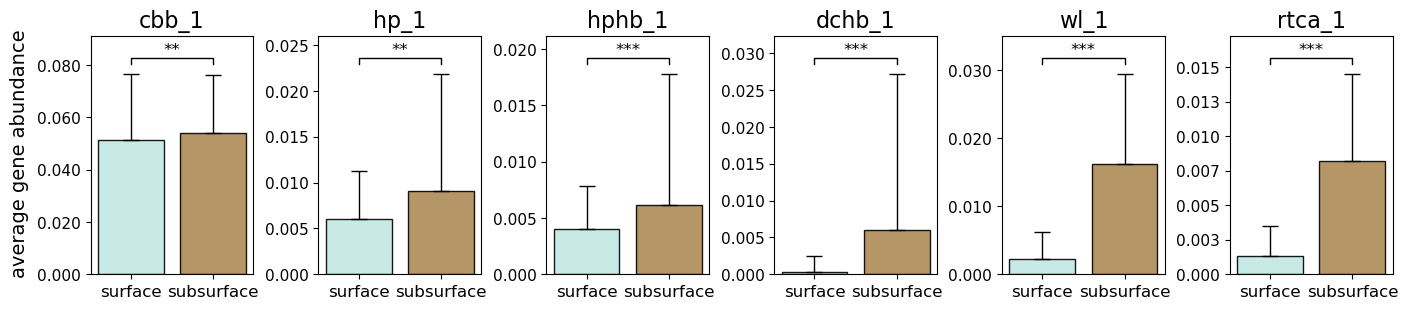

In [6]:
raw_pvals = []
for col in cfp_cols:
    d_surf = sample_table.loc[sample_table["surface_subsurface"] == "surface", col].dropna()
    d_sub  = sample_table.loc[sample_table["surface_subsurface"] == "subsurface", col].dropna()
    _, p = mannwhitneyu(d_surf, d_sub, alternative="two-sided")
    raw_pvals.append(p)

raw_pvals = np.array(raw_pvals, dtype=float)
sorted_idx = np.argsort(raw_pvals)
corrected_pvals = np.empty(len(raw_pvals))
for rank, idx in enumerate(sorted_idx):
    corrected_pvals[idx] = min(raw_pvals[idx] * (len(raw_pvals) - rank), 1.0)
corrected_pvals[sorted_idx] = np.maximum.accumulate(corrected_pvals[sorted_idx])

fig, axes = plt.subplots(1, len(cfp_cols), figsize=(2.8 * len(cfp_cols), 3.1))
axes = np.atleast_1d(axes)

for ax, col, p_corr in zip(axes, cfp_cols, corrected_pvals):

        
    means = sample_table.groupby("surface_subsurface")[col].mean().reindex(ordered_groups).values
    stds  = sample_table.groupby("surface_subsurface")[col].std().reindex(ordered_groups).values

    ax.set_facecolor("white")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))
    ax.bar(
        ordered_groups,
        means,
        yerr=[np.zeros_like(stds), stds],
        color=[color_surface_subsurface[g] for g in ordered_groups],
        alpha=0.9,
        edgecolor="black",
        linewidth=1,
        error_kw=dict(ecolor="black", capsize=6, lw=1)
    )

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_title(col.split("mean_")[-1], fontsize=16)

    for spine in ax.spines.values():
        spine.set_color("black")

    label = star(p_corr) or "ns"

    ymax = (means + stds).max()
    y_bar = ymax * 1.05
    h = ymax * 0.03
    y_star = y_bar + h * 1.2

    ax.plot([0, 0, 1, 1], [y_bar, y_bar + h, y_bar + h, y_bar], lw=1, c="black")
    ax.text(0.5, y_star, label, ha="center", va="bottom", fontsize=12)

    ax.set_ylim(0, y_star * 1.1)
    
fig.supylabel("average gene abundance", fontsize=14, x=0.077)
fig.subplots_adjust(wspace=0.4)

plt.savefig("../outputs/CFP_abundance_per_CFP.svg", bbox_inches="tight", transparent=True)
plt.show()

# Detail of each sample type

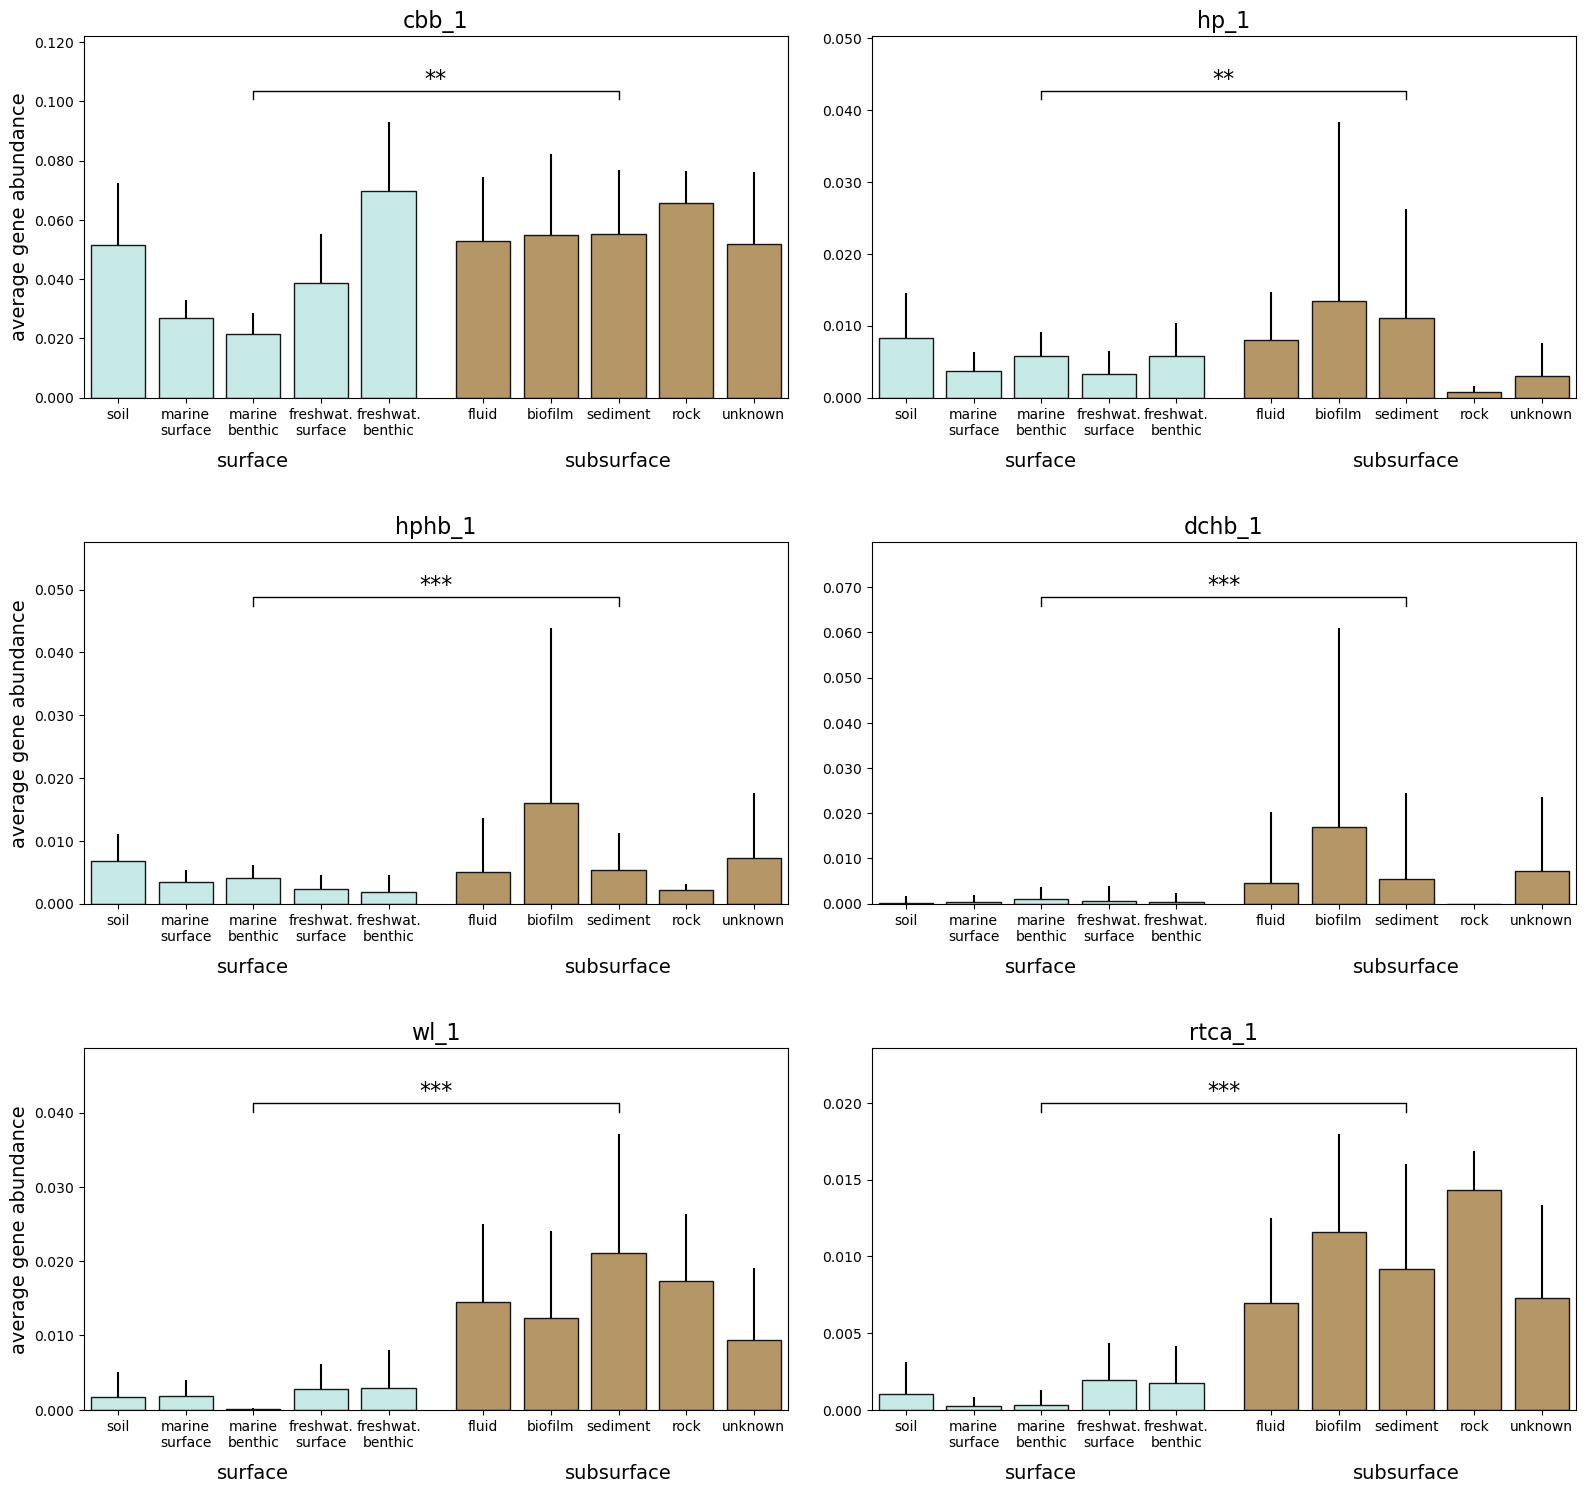

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()


display_names = {
    'terrestrial_soil': "soil",
    'marine_surface': "marine\nsurface",
    'marine_benthic': "marine\nbenthic",
    'freshwater_surface': "freshwat.\nsurface",
    'freshwater_benthic': "freshwat.\nbenthic",
    'subsurface_fluid': "fluid",
    'subsurface_biofilm': "biofilm",
    'subsurface_sediment': "sediment",
    'subsurface_rock': "rock",
    'subsurface': "unknown"
}

plot_order = [
    'terrestrial_soil',
    'marine_surface',
    'marine_benthic',
    'freshwater_surface',
    'freshwater_benthic',
    'subsurface_fluid',
    'subsurface_biofilm',
    'subsurface_sediment',
    'subsurface_rock',
    'subsurface'
]


for ax, col in zip(axes, cfp_cols):

    tmp = sample_table.copy()
    tmp["sample_subgroup"] = tmp["sample_subgroup"].map(display_names)

    stats = (
        tmp
        .groupby(["surface_subsurface", "sample_subgroup"])[col]
        .agg(["mean", "std"])
    )

    ax.set_facecolor("white")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

    surf_groups = [g for g in plot_order if ("surface", display_names[g]) in stats.index]
    sub_groups  = [g for g in plot_order if ("subsurface", display_names[g]) in stats.index]

    surf_labels = [display_names[g] for g in surf_groups]
    sub_labels  = [display_names[g] for g in sub_groups]

    x_surf = np.arange(len(surf_labels))
    gap = 0.4
    x_sub = np.arange(len(sub_labels)) + len(x_surf) + gap

    y_top = 0

    # surface bars
    for i, g in enumerate(surf_groups):
        mean = stats.loc[("surface", display_names[g]), "mean"]
        std  = stats.loc[("surface", display_names[g]), "std"]

        ax.bar(
            x_surf[i],
            mean,
            yerr=[[0], [std]],
            color=color_surface_subsurface["surface"],
            edgecolor="black",
            linewidth=1,
            alpha=0.9
        )

        y_top = max(y_top, mean + std)

    # subsurface bars
    for i, g in enumerate(sub_groups):
        mean = stats.loc[("subsurface", display_names[g]), "mean"]
        std  = stats.loc[("subsurface", display_names[g]), "std"]

        ax.bar(
            x_sub[i],
            mean,
            yerr=[[0], [std]],
            color=color_surface_subsurface["subsurface"],
            edgecolor="black",
            linewidth=1,
            alpha=0.9
        )

        y_top = max(y_top, mean + std)

    # xticks
    xticks = np.concatenate([x_surf, x_sub])
    xticklabels = surf_labels + sub_labels

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=10)

    # remove horizontal padding
    ax.margins(x=0)

    # explicit x-limits to remove empty space
    x_min = -0.5
    x_max = x_sub[-1] + 0.5 if len(x_sub) > 0 else x_surf[-1] + 0.5
    ax.set_xlim(x_min, x_max)

    # group labels
    if len(x_surf) > 0:
        ax.text(
            x_surf.mean(),
            -0.15,
            "surface",
            ha="center",
            va="top",
            fontsize=14,
            transform=ax.get_xaxis_transform()
        )

    if len(x_sub) > 0:
        ax.text(
            x_sub.mean(),
            -0.15,
            "subsurface",
            ha="center",
            va="top",
            fontsize=14,
            transform=ax.get_xaxis_transform()
        )

    # stats test
    d_surf = tmp.loc[tmp["surface_subsurface"] == "surface", col].dropna()
    d_sub  = tmp.loc[tmp["surface_subsurface"] == "subsurface", col].dropna()

    if len(d_surf) > 0 and len(d_sub) > 0:
        _, p = mannwhitneyu(d_surf, d_sub, alternative="two-sided")

        if p < 0.001:
            label = "***"
        elif p < 0.01:
            label = "**"
        elif p < 0.05:
            label = "*"
        else:
            label = "ns"

        y_bar = y_top * 1.08
        h = y_top * 0.03

        x1 = x_surf.mean() if len(x_surf) > 0 else 0
        x2 = x_sub.mean() if len(x_sub) > 0 else 1

        ax.plot([x1, x1, x2, x2],
                [y_bar, y_bar + h, y_bar + h, y_bar],
                lw=1, c="black")

        ax.text((x1 + x2) / 2, y_bar + h * 1.1, label,
                ha="center", va="bottom", fontsize=16)

        y_top = max(y_top, y_bar + h)

    ax.set_ylim(0, y_top * 1.18)

    ax.set_title(col.split("mean_")[-1], fontsize=16)

    for spine in ax.spines.values():
        spine.set_color("black")

# y-label only left column
for i, ax in enumerate(axes):
    if i % 2 == 0:
        ax.set_ylabel("average gene abundance", fontsize=14)
    else:
        ax.set_ylabel("")

fig.tight_layout()

# spacing between subplots
fig.subplots_adjust(wspace=0.12, hspace=0.4)

plt.savefig("../outputs/CFP_abundance_per_CFP_subgroup.svg", bbox_inches="tight", transparent=True)



plt.show()

# MA plot: Surface-subsurface enrichment for each KO

/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77360/3578873047.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_abundance[idx],
/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77360/3578873047.py:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  log2fc[idx],
/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77360/3578873047.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x=mean_abundanc

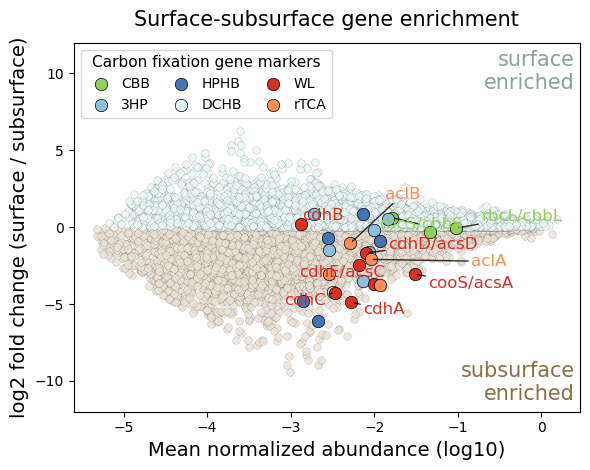

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.8))

mean_abundance = np.log10(
    (shared_otu[surface_samples].mean(axis=1) + shared_otu[subsurface_samples].mean(axis=1)) / 2
)

log2fc = np.log2(
    (shared_otu[surface_samples].mean(axis=1) + 1e-9) /
    (shared_otu[subsurface_samples].mean(axis=1) + 1e-9)
)

pathway_labels = {
    "cbb_1": "CBB",
    "hp_1": "3HP",
    "hphb_1": "HPHB",
    "dchb_1": "DCHB",
    "wl_1": "WL",
    "rtca_1": "rTCA"
}

ax.scatter(
    mean_abundance[log2fc < 0],
    log2fc[log2fc < 0],
    color=np.array(to_rgb(color_surface_subsurface["subsurface"])) + (1 - np.array(to_rgb(color_surface_subsurface["subsurface"]))) * 0.75,
    s=30,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.1
)

ax.scatter(
    mean_abundance[log2fc > 0],
    log2fc[log2fc > 0],
    color=np.array(to_rgb(color_surface_subsurface["surface"])) + (1 - np.array(to_rgb(color_surface_subsurface["surface"]))) * 0.65,
    s=30,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.1
)

for pw, color in color_pathway.items():
    mask = (
        shared_otu.index.isin(tax.index)
        & tax.loc[shared_otu.index, "key_genes"].str.contains(pw, na=False, case=False)
    )
    ax.scatter(
        mean_abundance[mask],
        log2fc[mask],
        color=color,
        edgecolors="black",
        linewidths=0.5,
        s=80,
        alpha=1,
        label=pathway_labels[pw]
    )

highlight_genes = [
    "rbcL/cbbL", "rbcS/cbbS", "aclA", "aclB", "cooS/acsA", "cdhA",
    "cdhC", "cdhD/acsD", "cdhB", "cdhE/acsC"
]
texts = []
highlight_indices = []

for gene in highlight_genes:
    mask_gene = shared_otu.index.isin(tax.index) & (tax.loc[shared_otu.index, "gene_name"] == gene)
    if mask_gene.any():
        idx = np.where(mask_gene)[0][0]
        highlight_indices.append(idx)
        pw_colors = [c for pw, c in color_pathway.items() if pw in str(tax.loc[shared_otu.index[idx], "key_genes"])]
        color = pw_colors[0] if pw_colors else "black"
        texts.append(
            ax.text(
                mean_abundance[idx],
                log2fc[idx],
                gene,
                fontsize=12,
                ha="left",
                va="center",
                color=color
            )
        )

adjust_text(
    texts,
    x=mean_abundance[highlight_indices],
    y=log2fc[highlight_indices],
    only_move={'text': 'xy'},
    force_text=(1.2, 1.8),
    expand=(1.5, 1.5),
    arrowprops=dict(arrowstyle='-', lw=1, alpha=0.8)
)

ax.set_xlabel("Mean normalized abundance (log10)", fontsize=14)
ax.set_ylabel("log2 fold change (surface / subsurface)", fontsize=14)
ax.set_ylim(-12, 12)
ax.set_title("Surface-subsurface gene enrichment", fontsize=15, pad=12)

ax.legend(
    [plt.scatter([], [], color=color_pathway[k], edgecolors="black", linewidths=0.5, s=80, label=v)
     for k, v in pathway_labels.items()],
    ["CBB", "3HP", "HPHB", "DCHB", "WL", "rTCA"],
    title="Carbon fixation gene markers",
    title_fontsize=11,
    ncol=3,
    bbox_to_anchor=(0.001, 1),
    loc="upper left",
    frameon=True,
    columnspacing=1.2,
    handletextpad=0.5
)

ax.text(
    0.99, 0.98,
    "surface\nenriched",
    color=np.array(to_rgb(color_surface_subsurface["surface"])) * 0.7,
    fontsize=15,
    transform=ax.transAxes,
    va="top",
    ha="right"
)

ax.text(
    0.99, 0.02,
    "subsurface\nenriched",
    color=np.array(to_rgb(color_surface_subsurface["subsurface"])) * 0.8,
    fontsize=15,
    transform=ax.transAxes,
    va="bottom",
    ha="right"
)

plt.tight_layout()
plt.savefig("../outputs/MA_plot.svg", transparent=True)
plt.show()